In [15]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import warnings
import os
import random
from keras.preprocessing.image import load_img

In [7]:
warnings.filterwarnings('ignore')

In [11]:
input_path=[]
label=[]
for Class in os.listdir("PetImages"):
    for path in os.listdir("PetImages/"+Class):
        if Class=='Cat':
            label.append(0)
        else:
            label.append(1)
        input_path.append(os.path.join("PetImages/",Class,path))
print(input_path[9302],label[9302])

PetImages/Cat/5756.jpg 0


In [45]:
df=pd.DataFrame()
df['images']=input_path
df['label']=label
df['label']=df['label'].astype('str')
df = df.sample(frac=1, random_state=42).reset_index(drop=True) #shuffle the data
df.head()

,images,label
0,PetImages/Cat/2621.jpg,0
1,PetImages/Dog/7716.jpg,1
2,PetImages/Cat/3410.jpg,0
3,PetImages/Dog/7468.jpg,1
4,PetImages/Dog/6571.jpg,1


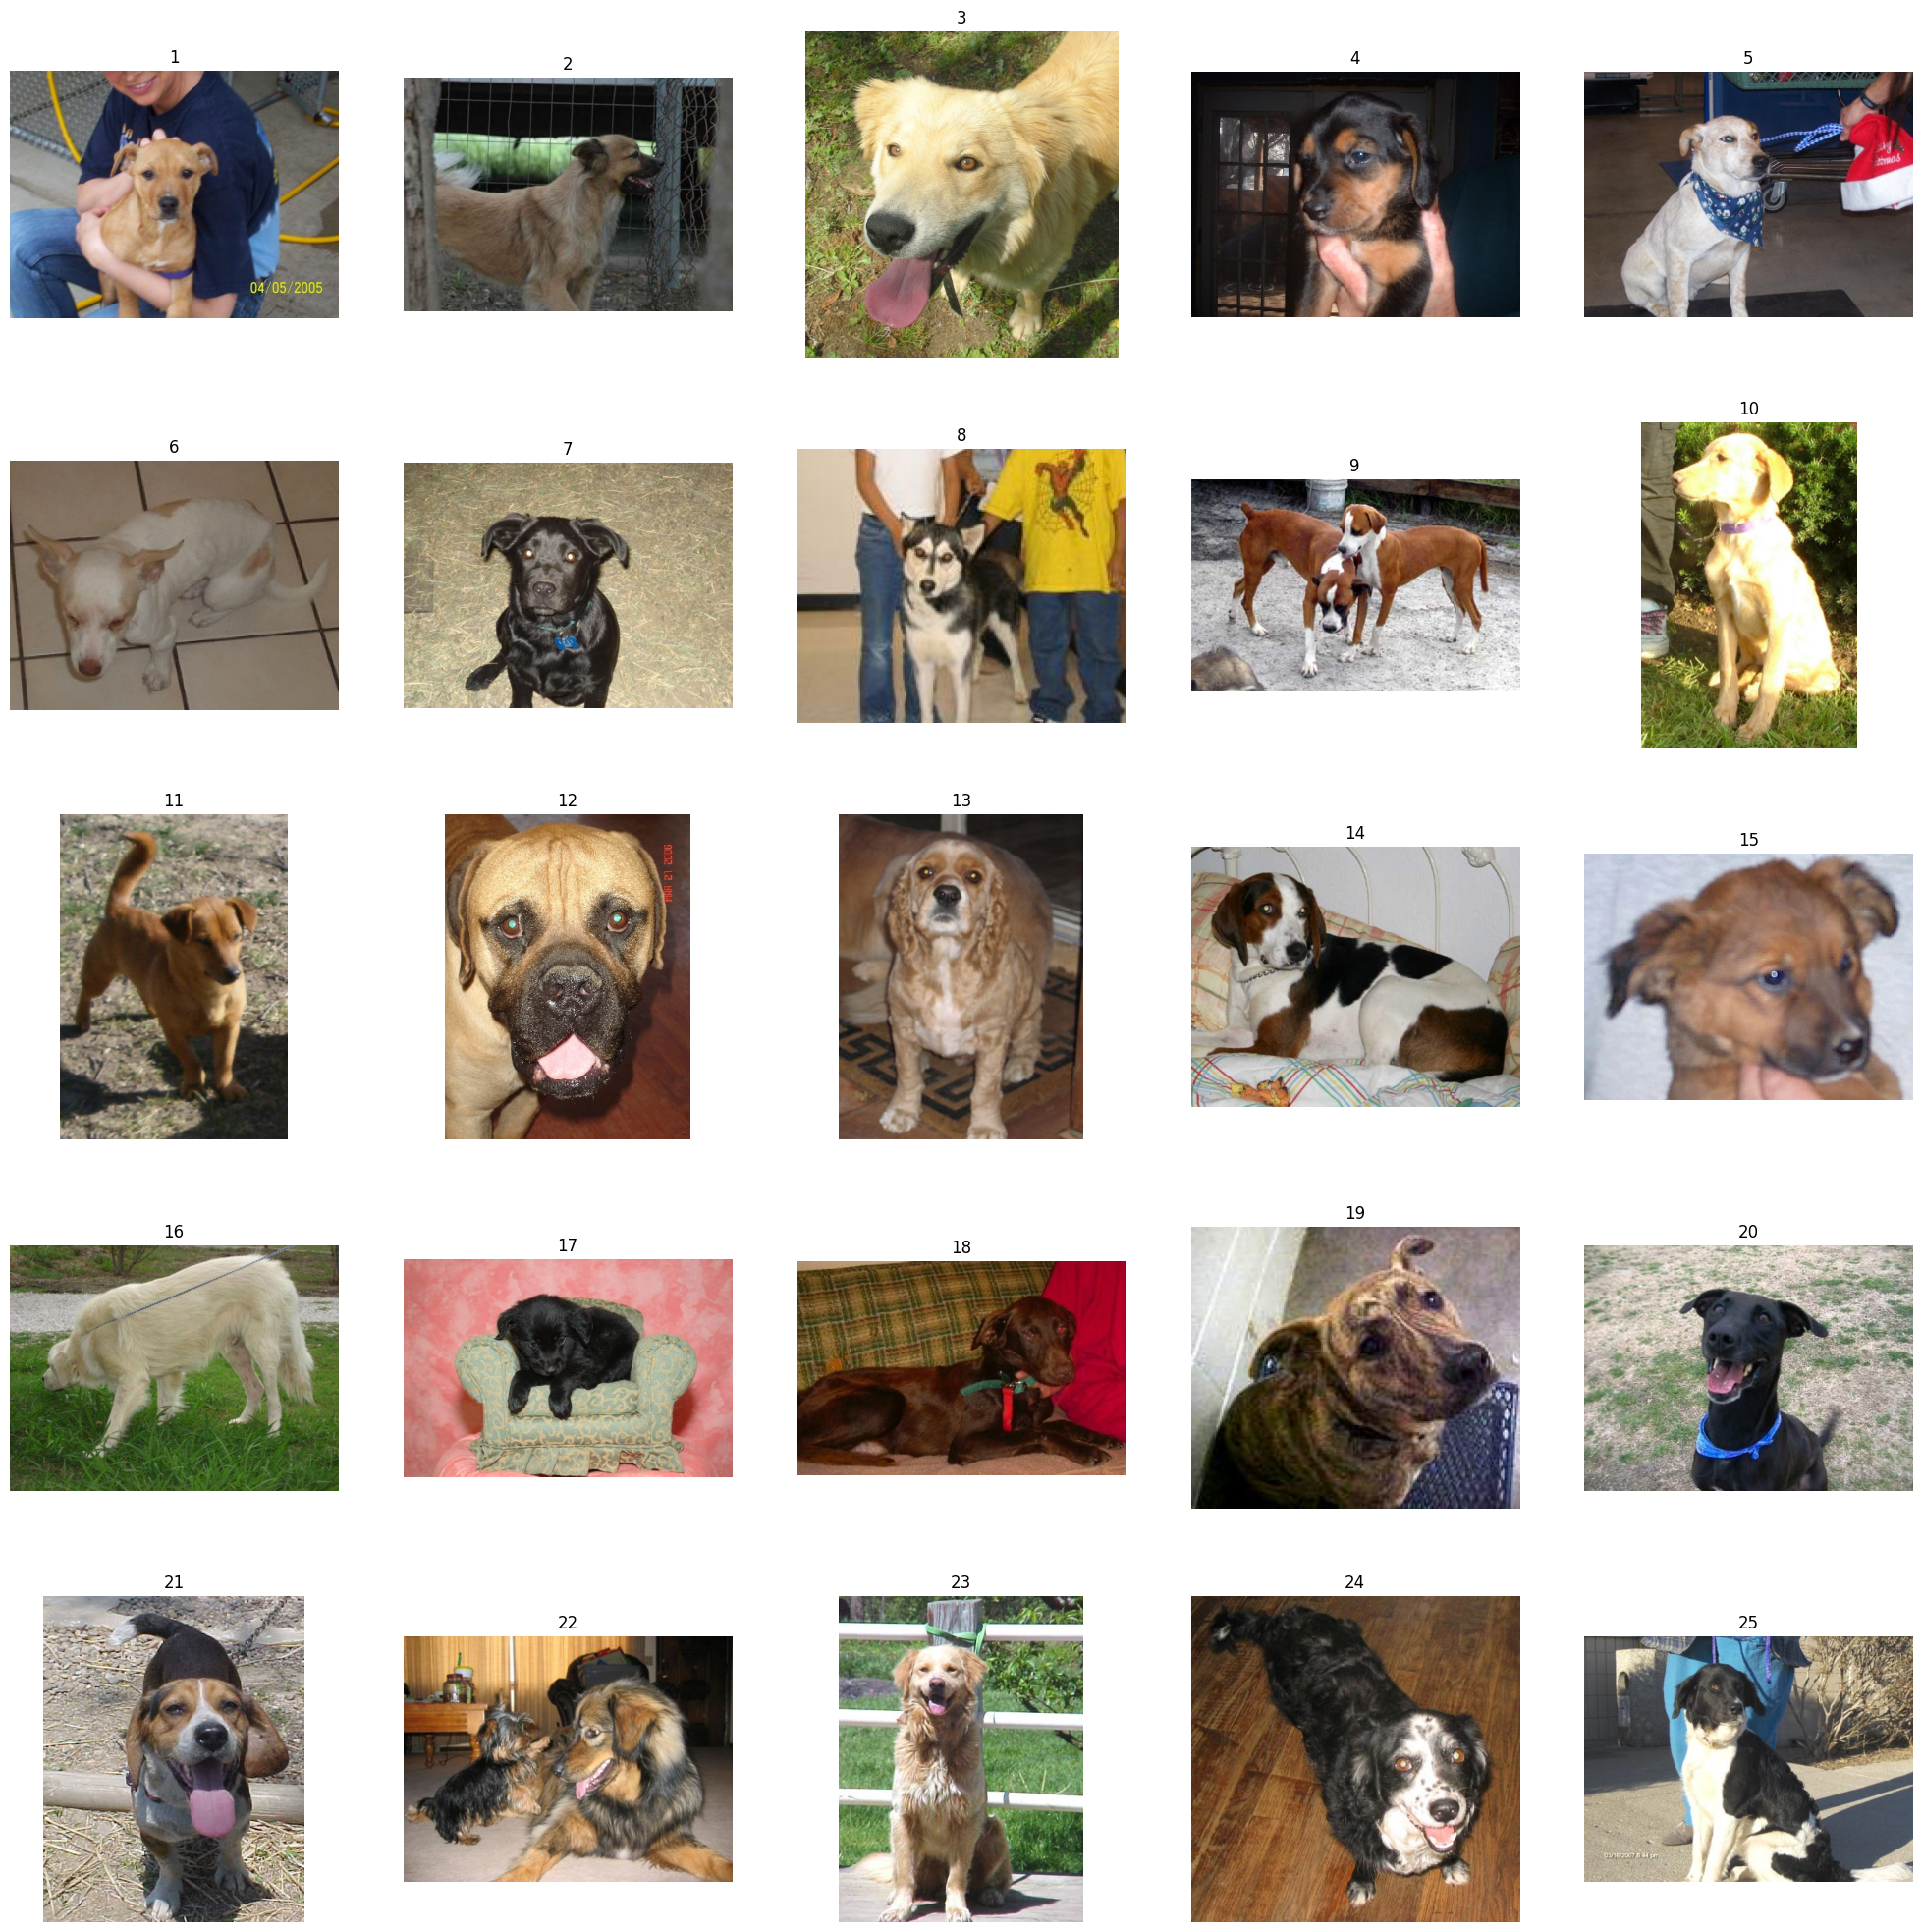

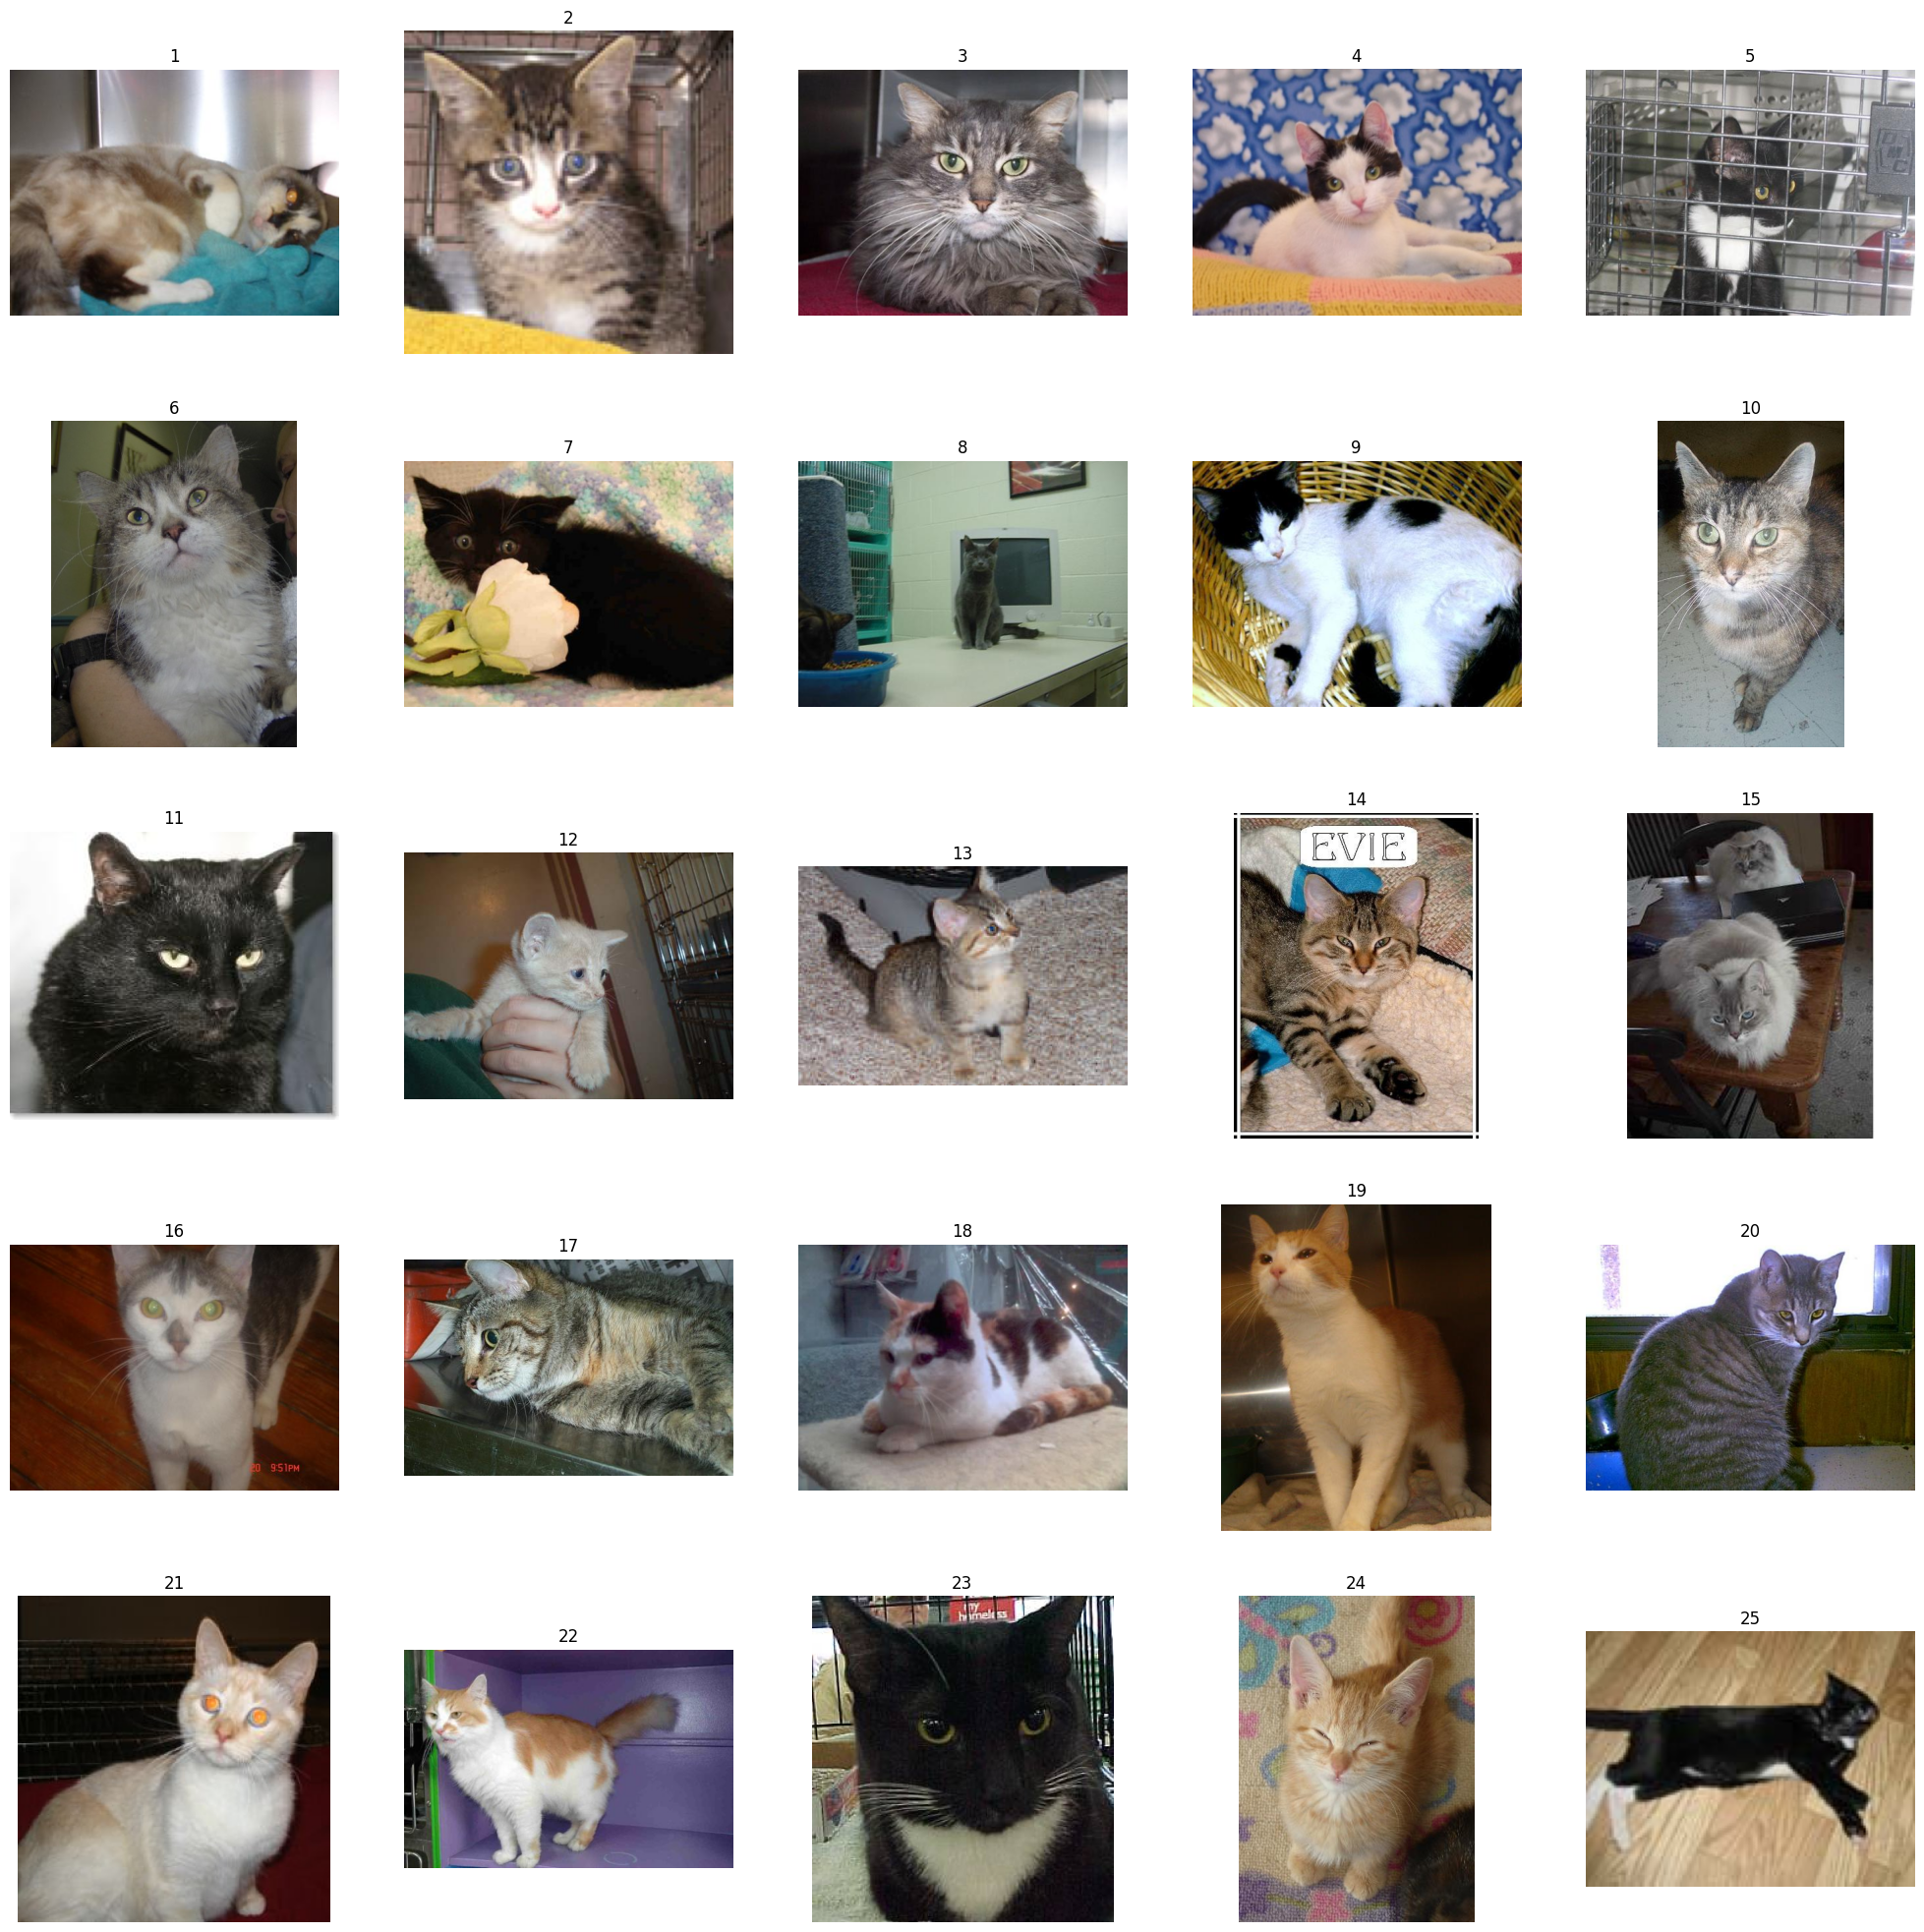

In [46]:
plt.figure(figsize=(25,25))
dog=df[df['label']=='1']['images']
cat=df[df['label']=='0']['images']
start=random.randint(0,len(dog)-25)
files=dog[start:start+25]
for index,file in enumerate(files):
    plt.subplot(5,5,index+1)
    img=load_img(file)
    img=np.array(img)
    plt.imshow(img)
    plt.title(index+1)
    plt.axis('off')
    
plt.figure(figsize=(25,25))
start=random.randint(0,len(cat)-25)
files=cat[start:start+25]
for index,file in enumerate(files):
    plt.subplot(5,5,index+1)
    img=load_img(file)
    img=np.array(img)
    plt.imshow(img)
    plt.title(index+1)
    plt.axis('off')

In [47]:
#create data generator for the images

In [53]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.2,random_state=42)

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator=ImageDataGenerator(
    rescale=1./255, #for normalizing the image
    rotation_range=40, #data augmentation
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_generator=ImageDataGenerator(rescale=1./255)

train_iterator=train_generator.flow_from_dataframe(train,x_col='images',y_col='label',target_size=(128,128),batch_size=64,class_mode='binary')

val_iterator=val_generator.flow_from_dataframe(test,x_col='images',y_col='label',target_size=(128,128),batch_size=64,class_mode='binary')

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [58]:
from keras import Sequential
from keras.layers import Conv2D,MaxPool2D,Flatten,Dense
model=Sequential([
    Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPool2D((2,2)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPool2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(512,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [61]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,137 (24.59 MB)

 Trainable params: 6,447,137 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history=model.fit(train_iterator,epochs=50,validation_data=val_iterator)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 116s 367ms/step - accuracy: 0.6420 - loss: 0.6251 - val_accuracy: 0.6858 - val_loss: 0.6129
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 342ms/step - accuracy: 0.7288 - loss: 0.5398 - val_accuracy: 0.7516 - val_loss: 0.5073
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 345ms/step - accuracy: 0.7530 - loss: 0.5015 - val_accuracy: 0.7756 - val_loss: 0.4661
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 350ms/step - accuracy: 0.7709 - loss: 0.4713 - val_accuracy: 0.7488 - val_loss: 0.5106
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 309ms/step - accuracy: 0.7819 - loss: 0.4554 - val_accuracy: 0.7386 - val_loss: 0.5224
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 340ms/step - accuracy: 0.8013 - loss: 0.4315 - val_accuracy: 0.8208 - val_loss: 0.3959
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 348ms/step - accuracy: 0.8093 - loss: 0.4149 - val_accuracy: 0.8272 - val_loss: 0.3962
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 325ms/step - accuracy: 0.8198 - 

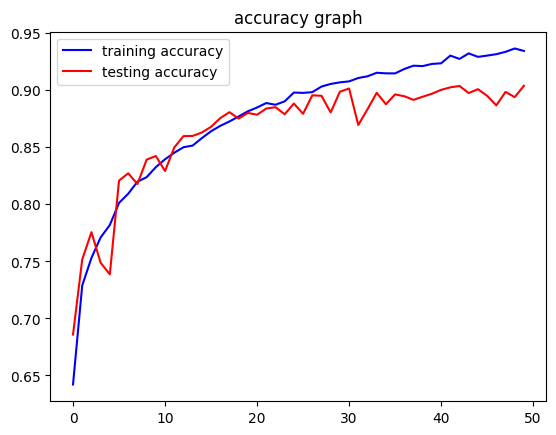

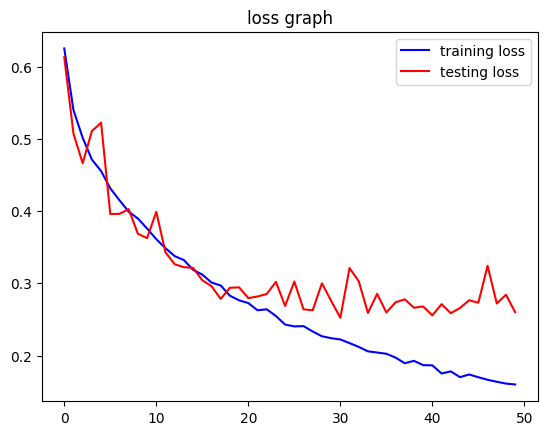

<Figure size 640x480 with 0 Axes>

final training accuracy =  0.9345434308052063
final validation accuracy =  0.9039999842643738
final training loss =  0.16000349819660187
final validation loss =  0.2599377930164337


In [74]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(len(acc))

plt.plot(epochs,acc,'b',label='training accuracy')
plt.plot(epochs,val_acc,'r',label='testing accuracy')
plt.title('accuracy graph')
plt.legend()
plt.figure()

loss=history.history['loss']
val_loss=history.history['val_loss']

plt.plot(epochs,loss,'b',label='training loss')
plt.plot(epochs,val_loss,'r',label='testing loss')
plt.title('loss graph')
plt.legend()
plt.figure()
plt.show()
print('final training accuracy = ',acc[len(acc)-1])
print('final validation accuracy = ',val_acc[len(val_acc)-1])
print('final training loss = ',loss[len(loss)-1])
print('final validation loss = ',val_loss[len(val_loss)-1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
prediction:
dog


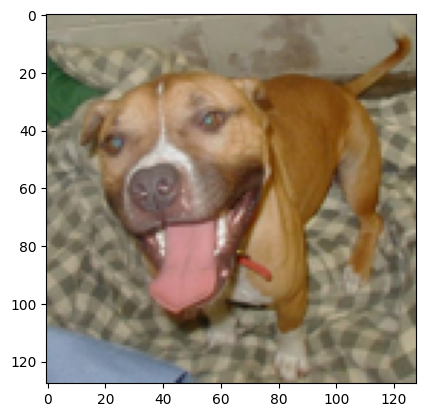

In [97]:
from PIL import Image
img=Image.open("PetImages/Dog/6.jpg")
img=img.resize((128,128))
img_arr=np.array(img)
img_array = img_arr / 255.0 #normalize
img_arr = np.expand_dims(img_arr, axis=0) #expand so that it is of the same format as batch
predict=model.predict(img_arr)
plt.imshow(img)
print('prediction:')
if(predict>0.5):
    print('dog')
else:
    print('cat')